# Experimentos con Datos con Desgaste y Segmentación
#### Estudiantes: Matías Carvajal y Daryl Clerc
#### Profesores: Pablo Estévez, Jorge Vergara
#### EL7037 - Primavera 2025

## Librerías y Funciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import sympy as sp

In [2]:
from sklearn.metrics import mean_squared_error

def eval_equations(x, y, equations):
    """
    Evalúa una lista de expresiones matemáticas contra los datos y calcula el MSE para cada una.

    :param x: dataframe con las variables
    :param y: variable objetivo
    :param equations: dataframe/lista con las expresiones obtenidas
    :return: lista de tuplas (expresión, MSE) ordenadas de menor a mayor MSE.
    """
    resultados = []

    for eq in equations:
        try:
            float(eq)
            resultados.append(np.inf)
        except ValueError:
            y_pred = eval(eq, {"__builtins__": {}, "np": np}, x.to_dict(orient='series'))
            mse = mean_squared_error(y, y_pred)
            resultados.append(mse)

    return pd.DataFrame({'expresiones': equations, 'mse': resultados})

In [3]:
def get_general_metrics(y_pred, y_true):
    """
    Calcula las métricas de error RMSE, MAE y SMAPE, junto con su desviación estándar.
    :param y_pred: Arreglo con los valores predichos por la ecuación obtenida.
    :param y_true: Arreglo con los valores reales de la variable.
    :return: Retorna un diccionario, donde los values son una tupla con el valor de la métrica
             y la desviación estándar; y las keys son los strings de las métricas calculadas
             i.e. 'RMSE', 'MAE, 'SMAPE'.
    """

    # Cálculo de errores
    errores_rmse = (y_true - y_pred) ** 2
    errores_mae = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    errores_smape = (np.abs(y_true - y_pred) / denominator) * 100

    # Cálculo de métricas
    rmse = np.round(np.sqrt(np.mean(errores_rmse)), 2)
    mae = np.round(np.mean(errores_mae), 2)
    smape = np.round(np.mean(errores_smape), 2)

    # Cálculo de desviaciones estándar
    std_rmse = np.round(np.std(np.sqrt(errores_rmse)), 2)
    std_mae = np.round(np.std(errores_mae), 2)
    std_smape = np.round(np.std(errores_smape), 2)

    # Retorna un diccionario con las métricas y sus desviaciones estándar
    return {
        "RMSE": (float(rmse), float(std_rmse)),
        "MAE": (float(mae), float(std_mae)),
        "SMAPE": (float(smape), float(std_smape))
    }

## Número de Nusselt

### Base de Datos

In [4]:
x_train = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_train_des.txt')
y_train = x_train['nusselt']
x_train = x_train.drop('nusselt', axis=1)
print('x_train:')
display(x_train.head())
print('y_train:', y_train.to_numpy()[: 5])

x_train:


,S,Re,Pr,SoH
0,0.280625,212.041256,0.709840,0.6363
1,0.280625,212.041256,0.707471,1.0000
2,0.280625,197.894331,0.706170,1.0000
3,0.344410,188.969448,0.708576,0.6363
4,0.344410,188.969448,0.704657,1.0000


y_train: [12.63272114 13.64363625 14.81134875 11.75386263 12.61276223]


In [5]:
x_min, x_max = x_train.min(), x_train.max()
xn_train = (x_train - x_min) / (x_max - x_min)
xn_train.head()

,S,Re,Pr,SoH
0,0.000000,0.078191,0.949814,0.333272
1,0.000000,0.078191,0.818411,1.000000
2,0.000000,0.072269,0.746265,1.000000
3,0.052307,0.068533,0.879694,0.333272
4,0.052307,0.068533,0.662373,1.000000


In [6]:
x_val = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_val_des.txt')
y_val = x_val['nusselt']
x_val = x_val.drop('nusselt', axis=1)
xn_val = (x_val - x_min) / (x_max - x_min)
xn_val.head()

,S,Re,Pr,SoH
0,0.621218,0.301473,0.989519,0.666544
1,0.621218,0.301473,0.969785,0.666544
2,0.621218,0.279105,0.957792,1.000000
3,0.621218,0.274098,0.953055,1.000000
4,0.621218,0.263788,0.944161,1.000000


### Segmentación

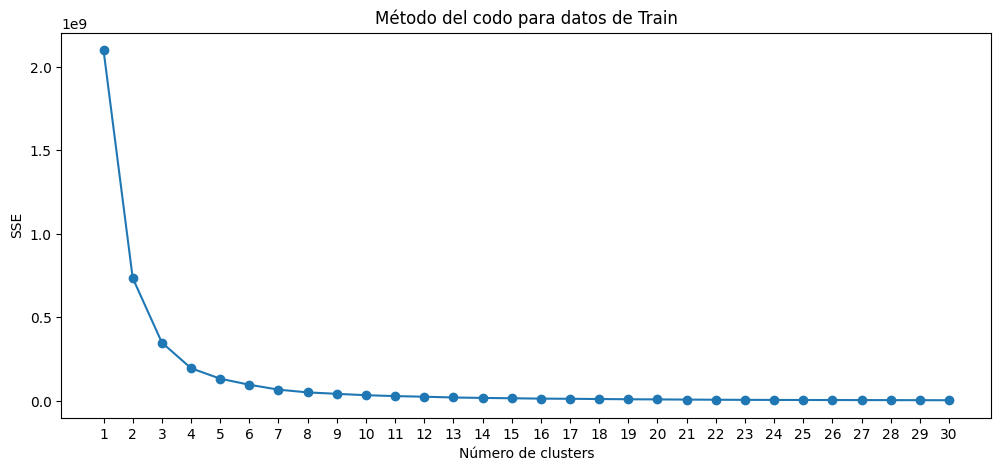

In [10]:
from sklearn.cluster import KMeans

sse=[]

for k in range(1, 31):
    kmeans = KMeans(n_clusters=k, random_state=41).fit(x_train)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(12, 5))
plt.plot(range(1, 31), sse, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('SSE')
plt.title('Método del codo para datos de Train')
plt.xticks(range(1, 31))
plt.show()

Óptimo cercano a 3, después de eso empieza a decaer lentamente la inercia. Podría ser 4, pero demasiada segmentación.

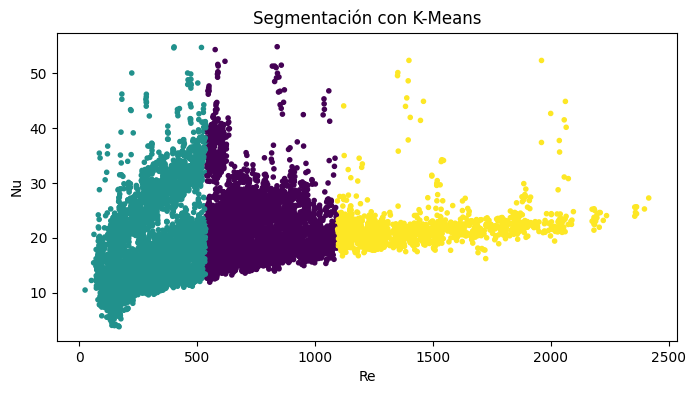

In [16]:
kmeans = KMeans(n_clusters=3, random_state=41)
clusters = kmeans.fit_predict(x_train)

plt.figure(figsize=(8, 4))
plt.title('Segmentación con K-Means')
plt.scatter(x_train['Re'], y_train, marker='.', c=clusters)
plt.xlabel('Re')
plt.ylabel('Nu')
plt.show()


### Regresión Simbólica

In [18]:
from time import time
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [22]:
x_train.rename(columns={'S': 'Se'}, inplace=True)
x_train['cluster'] = clusters

model = PySRRegressor(
    niterations=200,
    binary_operators=["+","-","*" ,"/", "^"],
    unary_operators=[],
    population_size=50,
    populations=4,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=2,
    random_state=0,
    progress=False
)

t0 = time()
model.fit(x_train, y_train)
tf = time()

print(f"Tiempo de ejecución: {tf - t0} [s]")

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
Compiling Julia backend...
C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that


Expressions evaluated per second: 9.790e+03
Progress: 12 / 800 total iterations (1.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.550e+01  0.000e+00  y = 20.014
4           4.372e+01  1.328e-02  y = Se + 19.115
6           4.219e+01  1.784e-02  y = (Re * 0.004609) + 17.164
7           4.218e+01  2.962e-04  y = 18.209 + (Se + Se)
10          3.909e+01  2.534e-02  y = ((Se - -0.87468) / (0.25867 ^ 1.803)) - 0.0062997
12          3.781e+01  1.671e-02  y = (((Se + (1.2234 / 0.25867)) ^ 1.803) + 0.083518) + -2....
                                      3179
14          3.750e+01  4.116e-03  y = (((Se - (-0.87468 / 0.25867)) ^ 1.803) - (0.0062997 + ...
                                      -0.67564)) / 0.721
19          3.611e+01  7.557e-03  y = -0.099741 + (((Se - -0.54791) / (

[ Info: Final population:
[ Info: Results saved to:


Tiempo de ejecución: 131.0570981502533 [s]
  - outputs\20250921_220418_0cNZxg\hall_of_fame.csv


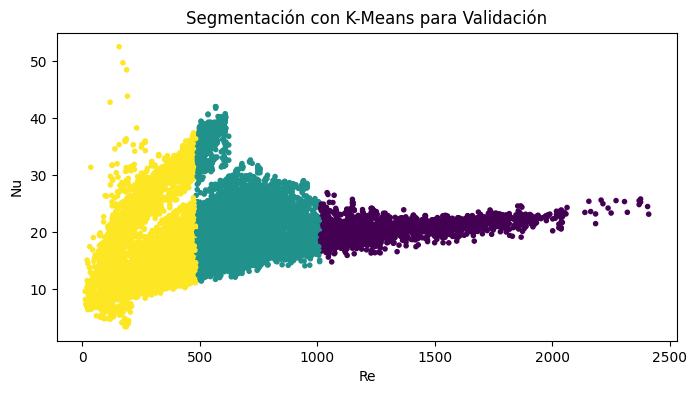

In [24]:
val_clusters = kmeans.fit_predict(x_val)
x_val['cluster'] = val_clusters

plt.figure(figsize=(8, 4))
plt.title('Segmentación con K-Means para Validación')
plt.scatter(x_val['Re'], y_val, marker='.', c=val_clusters)
plt.xlabel('Re')
plt.ylabel('Nu')
plt.show()

In [25]:
equations = model.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(x_train, y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
x_val.rename(columns={'S': 'Se'}, inplace=True)
df_val = eval_equations(x_val, y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
9,(-1818.3246 / Re) + ((Se + ((Se + SoH) + (Se *...,19.601381
8,(Se ** 7.2565575) + (((Se + (-0.95135075 / SoH...,19.714600
7,((Se ** 7.258251) + (22.078783 + (-1817.9545 /...,19.768880
6,((Se ** 7.0903163) + (Se + (-1817.9755 / Re)))...,20.128965
5,(21.94364 + (-1818.3246 / (Re + 2.5174131))) +...,20.399791
4,((Se ** 7.236495) + 21.94364) + (-1818.3246 / Re),20.471858
3,(Se ** 6.510032) + (18.493118 - cluster),33.369975
2,(Se ** 6.4748063) + 17.789375,34.314618
1,Se + 19.114988,43.724883
0,20.014498,inf



=== VALIDATION ===


,expresiones,mse
5,(21.94364 + (-1818.3246 / (Re + 2.5174131))) +...,22.299127
9,(-1818.3246 / Re) + ((Se + ((Se + SoH) + (Se *...,23.294428
7,((Se ** 7.258251) + (22.078783 + (-1817.9545 /...,23.418348
8,(Se ** 7.2565575) + (((Se + (-0.95135075 / SoH...,23.475220
6,((Se ** 7.0903163) + (Se + (-1817.9755 / Re)))...,23.901776
4,((Se ** 7.236495) + 21.94364) + (-1818.3246 / Re),24.413042
3,(Se ** 6.510032) + (18.493118 - cluster),26.007647
2,(Se ** 6.4748063) + 17.789375,30.157986
1,Se + 19.114988,39.760861
0,20.014498,inf


In [32]:
valid_exp = df_val['expresiones'][
    df_val['expresiones'].apply(lambda x: True if 'cluster' in x else False)
]
expr = sp.sympify(
    valid_exp.iloc[0]
).evalf(4)
expr

Se**6.51 - cluster + 18.49

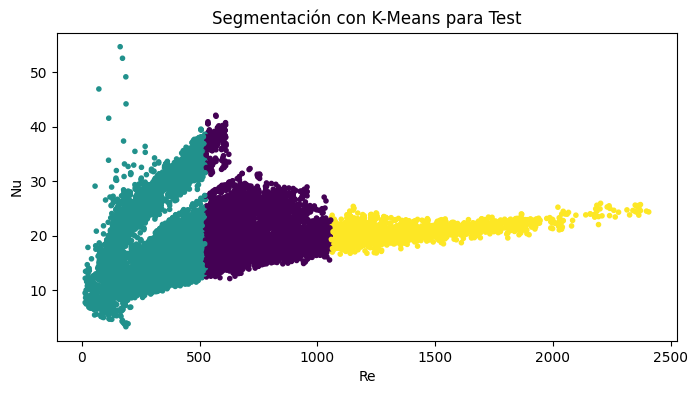

In [27]:
x_test = pd.read_csv(r'.\DATA_LIB_Degradation\df_n_test_des.txt')
y_true = x_test['nusselt']
x_test = x_test.drop('nusselt', axis=1)

test_clusters = kmeans.fit_predict(x_test)
x_test['cluster'] = test_clusters

plt.figure(figsize=(8, 4))
plt.title('Segmentación con K-Means para Test')
plt.scatter(x_test['Re'], y_true, marker='.', c=test_clusters)
plt.xlabel('Re')
plt.ylabel('Nu')
plt.show()

In [33]:
f = sp.lambdify(sp.symbols('Re SoH Se Pr cluster'), expr, 'numpy')
y_pred = f(x_test['Re'].to_numpy(),
           x_test['SoH'].to_numpy(),
           x_test['S'].to_numpy(),
           x_test['Pr'].to_numpy(),
           x_test['cluster'].to_numpy())
print('y_pred =', y_pred[: 5])
print('n_pred =', len(y_pred), '/ n_true =', len(y_true))
print()

results = get_general_metrics(y_pred, y_true)
for key, value in results.items():
    print(key, '=', value[0], '+/-', value[1])

y_pred = [17.49025545 17.49025545 17.49025545 17.49025545 17.49025545]
n_pred = 15731 / n_true = 15731

RMSE = 5.23 +/- 2.95
MAE = 4.32 +/- 2.95
SMAPE = 22.93 +/- 17.27


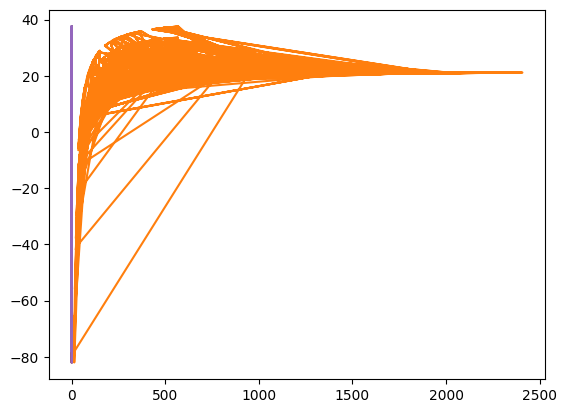

In [30]:
plt.plot(x_test[['']], y_pred)
plt.show()